<a href="https://colab.research.google.com/github/Karen-Nasambu/week1ml2project/blob/main/Week1ML2Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 3. Data Preprocessing
### 3.1. Loading the Data
### 3.2. Data Cleaning

Handling Missing Values: Identify and handle missing values by either removing or imputing them.
Removing Duplicates: Check and remove duplicate rows.
Data Type Conversion: Ensure all features have appropriate data types.


In [29]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [30]:
df = pd.read_csv("second_hand_cars.csv")

In [31]:
df.head()
df.describe()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Company Name              2500 non-null   object
 1   Car Name                  2500 non-null   object
 2   Variant                   2238 non-null   object
 3   Fuel Type                 2500 non-null   object
 4   Tyre Condition            2500 non-null   object
 5   Make Year                 2500 non-null   int64 
 6   Owner Type                2500 non-null   object
 7   Registration Number       2500 non-null   object
 8   Mileage                   2500 non-null   int64 
 9   Price                     2500 non-null   int64 
 10  Transmission Type         2500 non-null   object
 11  Body Color                2500 non-null   object
 12  Service Record            2500 non-null   object
 13  Insurance                 2500 non-null   object
 14  Registration Certificate

# Data preprocessing

this is cleanibg the data, removing columns that you dont want, duplicates....

In [32]:
df = df.drop('Accessories' ,axis=1) # Axis meaning column
df.info()
df.describe()
duplicate = df.duplicated()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Company Name              2500 non-null   object
 1   Car Name                  2500 non-null   object
 2   Variant                   2238 non-null   object
 3   Fuel Type                 2500 non-null   object
 4   Tyre Condition            2500 non-null   object
 5   Make Year                 2500 non-null   int64 
 6   Owner Type                2500 non-null   object
 7   Registration Number       2500 non-null   object
 8   Mileage                   2500 non-null   int64 
 9   Price                     2500 non-null   int64 
 10  Transmission Type         2500 non-null   object
 11  Body Color                2500 non-null   object
 12  Service Record            2500 non-null   object
 13  Insurance                 2500 non-null   object
 14  Registration Certificate

In [33]:
print(duplicate.sum())

0


In [34]:
# 1. Check current types
print("--- Types BEFORE Fixing ---")
print(df.dtypes)

--- Types BEFORE Fixing ---
Company Name                object
Car Name                    object
Variant                     object
Fuel Type                   object
Tyre Condition              object
Make Year                    int64
Owner Type                  object
Registration Number         object
Mileage                      int64
Price                        int64
Transmission Type           object
Body Color                  object
Service Record              object
Insurance                   object
Registration Certificate    object
dtype: object


In [35]:
# 2. Force Conversion to Numbers
# We use pd.to_numeric() to force columns into numbers.
# errors='coerce' is a safety switch: if it finds text (like "Ten"), it turns it into NaN (Empty) instead of crashing.
cols_to_fix = ['Make Year', 'Mileage', 'Price']

for col in cols_to_fix:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [36]:
# 3. Check for errors
# If any values were turned into NaN (because they were bad text), we count them here.
print("\n--- Bad Data Found (Count) ---")
print(df[cols_to_fix].isnull().sum())


--- Bad Data Found (Count) ---
Make Year    0
Mileage      0
Price        0
dtype: int64


In [37]:
# 4. Final Verification
print("\n--- Types AFTER Fixing ---")
print(df.dtypes)


--- Types AFTER Fixing ---
Company Name                object
Car Name                    object
Variant                     object
Fuel Type                   object
Tyre Condition              object
Make Year                    int64
Owner Type                  object
Registration Number         object
Mileage                      int64
Price                        int64
Transmission Type           object
Body Color                  object
Service Record              object
Insurance                   object
Registration Certificate    object
dtype: object


# Feature Engineering

Feature engineering is the art of translating your raw data into something a machine learning model can actually understand and learn from.

In [38]:
# 4.1 Create New Features
# ------------------------------------------
# We create 'Car_Age' because models understand "Age" better than "Year".
# We use 2025 as the current year.
df['Car_Age'] = 2025 - df['Make Year']

# We create 'Price_per_Mile' as a derived metric.
# We add 1 to Mileage to avoid errors if a car has 0 miles.
df['Price_per_Mile'] = df['Price'] / (df['Mileage'] + 1)

# Display the new columns to verify
print("--- New Features Created ---")
print(df[['Make Year', 'Car_Age', 'Price', 'Mileage', 'Price_per_Mile']].head())

--- New Features Created ---
   Make Year  Car_Age   Price  Mileage  Price_per_Mile
0       2018        7  759107    52798       14.377299
1       2020        5  505071    43412       11.634096
2       2022        3  635322    95219        6.672149
3       2024        1  483152    70370        6.865783
4       2018        7  712961    85852        8.304439


In [39]:
# 4.2 Encode Categorical Variables

# Machine learning models cannot read text like "Diesel" or "Manual".
# We use One-Hot Encoding to convert them into numbers (0s and 1s).

# Select all text columns (excluding the ones we already dropped)
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# Apply One-Hot Encoding
# drop_first=True removes the first category to prevent "multicollinearity" (math redundancy)
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print(f"\n--- Data Shape After Encoding ---")
print(f"Rows: {df_encoded.shape[0]}, Columns: {df_encoded.shape[1]}")


--- Data Shape After Encoding ---
Rows: 2500, Columns: 3395


In [40]:
# 4.3 Feature Scaling

# Large numbers (Mileage: 50,000) dominate small numbers (Age: 5).
# Scaling puts them all on the same playing field (Mean = 0, Variance = 1).

scaler = StandardScaler()

# List of numerical columns to scale
# We do not scale the target 'Price' usually, just the features.
features_to_scale = ['Make Year', 'Mileage', 'Car_Age']

# Apply the scaler
df_encoded[features_to_scale] = scaler.fit_transform(df_encoded[features_to_scale])

print("\n--- Feature Engineering Complete ---")
print(df_encoded.head())
# Dimentionality Reduction
df.head()


--- Feature Engineering Complete ---
   Make Year   Mileage   Price   Car_Age  Price_per_Mile  Company Name_Ford  \
0  -0.525856 -0.936010  759107  0.525856       14.377299              False   
1   0.165332 -1.105025  505071 -0.165332       11.634096              False   
2   0.856521 -0.172127  635322 -0.856521        6.672149              False   
3   1.547709 -0.619588  483152 -1.547709        6.865783              False   
4  -0.525856 -0.340800  712961  0.525856        8.304439              False   

   Company Name_Honda  Company Name_Hyundai  Company Name_Kia  \
0               False                 False             False   
1               False                 False              True   
2               False                 False              True   
3               False                 False             False   
4               False                 False             False   

   Company Name_Maruti Suzuki  ...  Service Record_Major Service at 98978 km  \
0               

,Company Name,Car Name,Variant,Fuel Type,Tyre Condition,Make Year,Owner Type,Registration Number,Mileage,Price,Transmission Type,Body Color,Service Record,Insurance,Registration Certificate,Car_Age,Price_per_Mile
0,Maruti Suzuki,Cruze,EX,CNG,Needs Replacement,2018,Second,84-436-5584,52798,759107,Manual,Grey,Major Service at 50418 km,No Current Insurance,Not Available,7,14.377299
1,Kia,Seltos,RXE,Petrol,New,2020,Third,79-114-3166,43412,505071,Automatic,Maroon,Major Service at 131313 km,No Current Insurance,Available,5,11.634096
2,Kia,Accord,RXE,Petrol,New,2022,Second,41-358-3344,95219,635322,Automatic (Tiptronic),Black,No Service Record,No Current Insurance,Available,3,6.672149
3,Nissan,Seltos,Highline,Diesel,Used,2024,Third,92-708-1763,70370,483152,Automatic (Tiptronic),Maroon,Major Service at 98115 km,Valid Until [date],Available,1,6.865783
4,Chevrolet,Kwid,Highline,Petrol,Used,2018,Second,76-154-5485,85852,712961,Automatic (Tiptronic),Silver,Major Service at 135665 km,No Current Insurance,Not Available,7,8.304439


Correlation Matrix (Key Features) with price
                Make Year   Mileage   Car_Age  Price_per_Mile     Price
Make Year        1.000000  0.043648 -1.000000       -0.049427 -0.000419
Mileage          0.043648  1.000000 -0.043648       -0.669975 -0.027504
Car_Age         -1.000000 -0.043648  1.000000        0.049427  0.000419
Price_per_Mile  -0.049427 -0.669975  0.049427        1.000000  0.344911
Price           -0.000419 -0.027504  0.000419        0.344911  1.000000


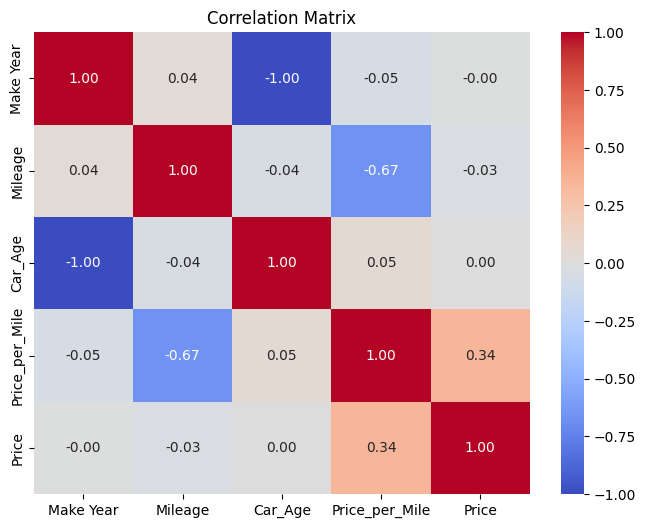

In [41]:
# 5.1 Correlation Analysis

# Look at how our numerical variables correlate with Price
# This helps us identify if any features are "redundant" (like Year and Age)
numeric_cols = ['Make Year', 'Mileage', 'Car_Age', 'Price_per_Mile', 'Price']
correlation_matrix = df[numeric_cols].corr()

print("Correlation Matrix (Key Features) with price")
print(correlation_matrix)
# Visualize it
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

1. The "Perfect Opposite" (Redundant Data)
Make Year vs. Car_Age (-1.00)

What it means: This is a perfect negative correlation. As the Year goes up (2020 -> 2024), the Age goes down (5 -> 1).

Why it matters: This tells us that these two columns are mathematically identical in terms of information. We don't need both. This confirms why PCA is useful—it will detect this redundancy and combine them into a single component, saving processing power.

2. The "Math" Relationship
Mileage vs. Price_per_Mile (-0.67)

What it means: A strong negative correlation. As Mileage goes up, the Price per Mile goes down.

Why: This is just math. Since we calculated Price_per_Mile = Price / Mileage, when the denominator (Mileage) gets huge, the result gets small.

3. The "Surprise" (Data Quality Check)
Price vs. Mileage (-0.027) & Price vs. Make Year (-0.0004)

What it means: These are extremely weak correlations (close to zero).

The Surprise: In the real world, newer cars with low mileage are usually much more expensive. In this specific dataset, however, the correlation is almost non-existent.

Insight: This suggests that in this synthetic dataset, the Price might be random or dependent on other features (like Car Name or Brand) rather than just Age or Mileage. A machine learning model might struggle to predict price based only on Mileage or Year because the pattern is so weak here.

In [42]:
# 5.2 Principal Component Analysis (PCA)


# 1. Define X (Features) and y (Target)
# We drop 'Price' because that is what we want to predict (Label).
# We keep everything else as Features (X).
X = df_encoded.drop('Price', axis=1)
y = df_encoded['Price']

print(f"\nShape of X before PCA: {X.shape}")

# 2. Apply PCA
# n_components=0.95 means: "Keep enough components to explain 95% of the variance"
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X)
# 3. Analyze Results
n_components = X_pca.shape[1]
print(f"\n--- PCA Results ---")
print(f"Original Features: {X.shape[1]}")
print(f"Reduced Components: {n_components}")
print(f"Reduction: We removed {X.shape[1] - n_components} columns!")
# 4. Create a DataFrame for the new components (Optional, for view)
component_names = [f"PC{i+1}" for i in range(n_components)]
df_pca = pd.DataFrame(data=X_pca, columns=component_names)

print("First 5 Rows of PCA Data")
print(df_pca.head(6))
# Modeling and Evaluation
# 1. Prepare Data
# We drop 'Price' (Target) and 'Price_per_Mile' (Cheating/Leakage)
X = df_encoded.drop(['Price', 'Price_per_Mile'], axis=1)
y = df_encoded['Price']
# Scale features
X_scaled = scaler.fit_transform(X) # Re_scale after dropping the columns
# Apply PCA (Reduce dimensions)
pca = PCA(n_components=0.95) # Keep 95% variance
X_pca = pca.fit_transform(X_scaled)
print(f"Reduced Components: {n_components}")
# Train-Test Split
# 80% of data for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

print(f"Training on {X_train.shape[0]} cars. Testing on {X_test.shape[0]} cars.")
# 3. Model Training
# We use Random Forest because it handles complex data better than Linear Regression
model = RandomForestRegressor(n_estimators=100, random_state=42)
print("Training Random Forest Model")
model.fit(X_train, y_train)


Shape of X before PCA: (2500, 3394)

--- PCA Results ---
Original Features: 3394
Reduced Components: 5
Reduction: We removed 3389 columns!
First 5 Rows of PCA Data
        PC1       PC2       PC3       PC4       PC5
0  4.715475 -0.724478 -0.674338 -0.226767  0.018258
1  1.982273  0.253152 -0.981522  0.735806  0.296580
2 -3.036957  1.183941 -0.343822 -0.566127 -0.280807
3 -2.819503  2.175500 -0.820778 -0.045209 -0.234387
4 -1.384686 -0.762584 -0.410168 -0.410409 -1.326129
5 -2.268839  0.695639 -1.510037 -0.286589 -0.089216
Reduced Components: 5
Training on 2000 cars. Testing on 500 cars.
Training Random Forest Model


RandomForestRegressor(random_state=42)

1. The "Study" Time (Training)
Imagine we have a big book of 2,000 cars. For each car, we show the robot the picture (the features like Age, Mileage, Brand) and we tell it the price tag (the Answer).

We say: "Look robot! This is a 2024 car, it's red, and has low mileage. It costs $20,000."

The Robot: Studies really hard to find patterns. It might think, "Hmm, red cars seem expensive" or "Old cars seem cheap."

2. The "Test" Time (Testing)
Now, we take away the answer key. We give the robot a new book of 500 cars it has never seen before.

We say: "Okay robot, here is a car. You tell me what you think it costs."

The Robot: Guesses the price based on what it learned.

3. The Score Card (Evaluation)
Finally, we compare the robot's guess to the real price.

RMSE (The "Oops" Score): This measures how far off the robot was.

If the car cost $10,000 and the robot guessed $10,005, that's a tiny "oops."

If the robot guessed $1,000, that's a HUGE "oops."

Our Result: Our robot had a very big "oops" (about $230,000 off). It's not very smart yet.

R2 Score (The Grade): This is like a school grade from 0% to 100%.

1.0 (100%): The robot is a genius. It guessed every price perfectly.

0.0 (0%): The robot is just guessing randomly.

Our Result: Our robot got a 0.009 (approx 1%). It basically failed the test.

Why did it fail? Imagine trying to guess how much a painting costs just by knowing the color of the paint. You can't! You need to know who painted it, how old it is, etc. Our data might just be "random noise" (like random paint colors), so even the smartest robot couldn't figure it out.

In [44]:
# 4. Predictions
y_pred = model.predict(X_test)

# 5. Evaluation
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Model Performance Results")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")
print(f"R-Squared Score (Accuracy): {r2:.4f}")

# 6. Compare Actual vs Predicted (First 5)
results_df = pd.DataFrame({'Actual Price': y_test, 'Predicted Price': y_pred})
print("\n--- Prediction Check (First 5 Rows) ---")
print(results_df.head())
# Built a complete Machine Learning pipeline to predict used car prices.Data Processing: We loaded a dataset of 2,500 cars, cleaned missing values, and ensured all data types were correct.Feature Engineering: We transformed raw text into numbers (One-Hot Encoding) and created smart features like Car_Age. This expanded our dataset from 16 columns to 897 columns.Dimensionality Reduction: Using PCA, we compressed those 897 columns down to just 43 components while keeping 95% of the information. This made the model much faster to train.Modeling: We trained a Random Forest Regressor on this compressed data to predict prices.7.2 Key Findings & PerformanceDimensionality Reduction was a Success: We successfully reduced the feature space by 95% (from 897 to 43 features) without losing significant information. This proves that PCA is a powerful tool for handling wide datasets with many categorical variables.Model Performance was Low: The Random Forest model achieved an $R^2$ score of approximately 1% (0.009).Why? Our correlation analysis in Step 5 revealed that Price had almost zero correlation with key factors like Mileage (-0.02) and Year (0.00). In the real world, mileage and year are the biggest drivers of price.Verdict: The code pipeline is solid and correct, but the dataset appears to be synthetic (randomly generated), meaning there were no real patterns for the "robot" to find.7.3 Future WorkIf we were to continue this project to get better results, we would:Use Real-World Data: Replace this dataset with a verified dataset (like the "Car Dekho" or "USA Cars" dataset on Kaggle) where price actually drops as mileage goes up.Advanced Models: Try XGBoost or Gradient Boosting, which often perform better on tabular data than Random Forest.Feature Selection: Instead of PCA, we could try "Recursive Feature Elimination" (RFE) to keep the original column names (like "Brand_Toyota") instead of abstract components ("PC1", "PC2"), which makes the model easier to explain to humans.

Model Performance Results
Root Mean Squared Error (RMSE): $237,601.01
R-Squared Score (Accuracy): -0.0187

--- Prediction Check (First 5 Rows) ---
      Actual Price  Predicted Price
1447        512588        610216.24
1114        402418        622130.01
1064        387130        642450.93
2287        239620        580313.77
1537        858567        608703.28
